#### Importing all the relevant libraries

In [1]:
# LinearRegression and mse from sklearn
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

# for normalization
from sklearn.preprocessing import MinMaxScaler

# for data loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### Loading the data

In [2]:
housing_df = pd.read_csv("kc_house_data.csv")

housing_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


##### Checking the Data information.

In [3]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

##### Drawing a scatter plot for Zipcode and and Price

Text(0, 0.5, 'price')

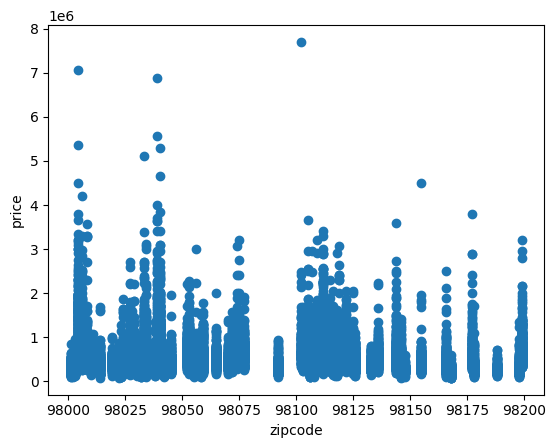

In [4]:

plt.scatter(housing_df['zipcode'], housing_df['price'])
plt.xlabel('zipcode')
plt.ylabel('price')

##### Checking the numerical features information

In [5]:
numerical_column = housing_df.select_dtypes(include=['int', 'float']).columns.tolist()
numerical_column

['id',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

##### Checking the correlations between the numerical features

In [6]:
housing_df[numerical_column].corr()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


##### Creating a correlation heatmap between three numerical features.

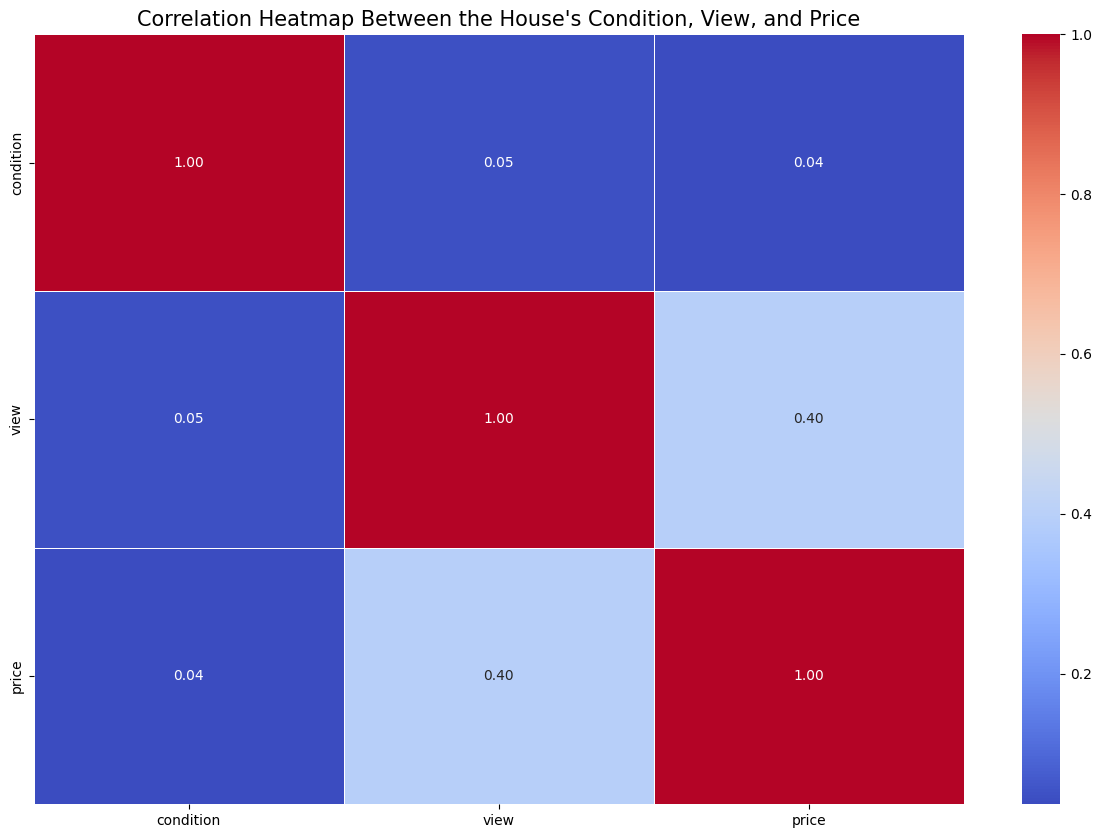

In [7]:
import seaborn as sns
corr = housing_df[["condition", "view", "price"]].corr()

plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap Between the House's Condition, View, and Price", fontsize=15)
plt.show()


##### Training the Linear Regression model

In [8]:
from sklearn.model_selection import train_test_split
housing_df_train, housing_df_test = train_test_split(housing_df, test_size=0.2, random_state=0)

In [9]:
linreg = LinearRegression()
linreg.fit(X=housing_df_train[["floors"]], y=housing_df_train["price"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### creating a model for the mean square error

In [10]:
train_mse_floors = mean_squared_error(housing_df_train["price"], linreg.predict(housing_df_train[["floors"]]))
test_mse_floors = mean_squared_error(housing_df_test["price"], linreg.predict(housing_df_test[["floors"]]))

In [11]:
train_mse_floors

129690437592.9068

In [12]:
test_mse_floors

110704254459.62538

##### Creating a scatter plot with the best fit line for the MSE

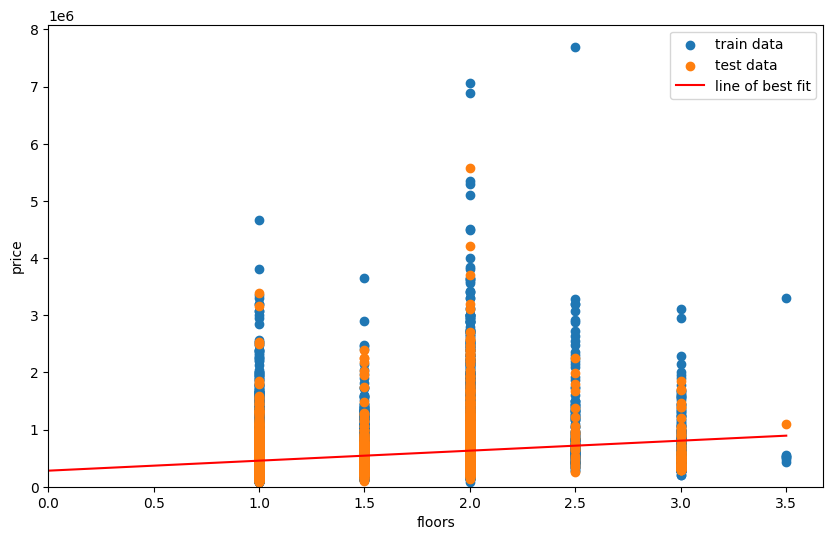

In [13]:
fig = plt.figure(figsize=(10,6))

# scatter plot for both train and test set
plt.scatter(housing_df_train["floors"], housing_df_train["price"], label="train data")
plt.scatter(housing_df_test["floors"], housing_df_test["price"], label="test data")

# predictions using y = ax + b
predictions = [linreg.coef_*i + linreg.intercept_ for i in [0, housing_df_train["floors"].max()]]

# plot the line based on the prediction
plt.plot([0, housing_df_train["floors"].max()], predictions, color="r", label="line of best fit")

plt.xlabel("floors"); plt.ylabel("price")
plt.ylim(0)
plt.xlim(0)
plt.legend();

In [14]:
housing_df_train[["price", "floors", "bathrooms"]]

,price,floors,bathrooms
5268,495000.0,1.0,1.00
16909,635000.0,1.0,2.50
16123,382500.0,1.0,1.50
12181,382500.0,2.0,2.50
12617,670000.0,2.0,2.50
...,...,...,...
13123,1180000.0,2.0,5.00
19648,299000.0,2.0,2.50
9845,431000.0,1.0,2.25
10799,411000.0,2.0,2.00


#### Creating a scaler for the Gradient Descent

In [15]:
scaler = MinMaxScaler()
scaler.fit(housing_df_train[["floors", "bathrooms"]])
result = scaler.transform(housing_df_train[["floors", "bathrooms"]])
scld_housing_df_train = housing_df_train[["price", "floors", "bathrooms"]].copy()
scld_housing_df_train["floors"] = result[:, 0]
scld_housing_df_train["bathrooms"] = result[:, 1]

scld_housing_df_train.head()

,price,floors,bathrooms
5268,495000.0,0.0,0.1250
16909,635000.0,0.0,0.3125
16123,382500.0,0.0,0.1875
12181,382500.0,0.4,0.3125
12617,670000.0,0.4,0.3125


In [16]:
linreg.fit(scld_housing_df_train[["floors", "bathrooms"]], scld_housing_df_train["price"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##### Training the MSE

In [17]:
# train mse
train_mse_floors_bathrooms = (
    mean_squared_error(scld_housing_df_train["price"], linreg.predict(scld_housing_df_train[["floors", "bathrooms"]]))
)

# test mse
# we first need to scale the test data
scld_housing_df_test = housing_df_test[["price", "floors","bathrooms"]].copy()
result = scaler.transform(scld_housing_df_test[["floors", "bathrooms"]])
scld_housing_df_test["floors"] = result[:, 0]
scld_housing_df_test["bathrooms"] = result[:, 1]
test_mse_floors_bathrooms = (
    mean_squared_error(scld_housing_df_test["price"], linreg.predict(scld_housing_df_test[["floors", "bathrooms"]]))
)
print(
    f"train mse (using floors and bathrooms) = {train_mse_floors_bathrooms}\n"
    f"test mse (using floors and bathrooms)  = {test_mse_floors_bathrooms}"
)

train mse (using floors and bathrooms) = 100443738240.08228
test mse (using floors and bathrooms)  = 86280519374.3893


##### Plotting a scatter plot

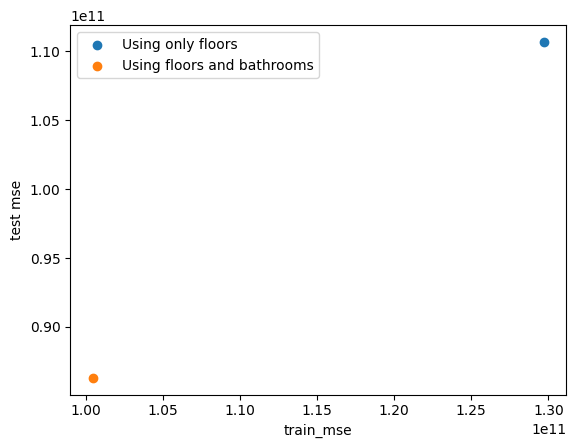

In [18]:
plt.scatter([train_mse_floors], [test_mse_floors], label="Using only floors")
plt.scatter([train_mse_floors_bathrooms], [test_mse_floors_bathrooms], label="Using floors and bathrooms")
plt.ylabel("test mse")
plt.xlabel("train_mse")
plt.legend()

In [19]:
numerical_feature_columns = [c for c in numerical_column if c != "price"]
numerical_feature_columns

['id',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

##### Training a model to check MSE in all the features

In [20]:
X_train = housing_df_train[numerical_feature_columns]
y_train = housing_df_train["price"]
X_test = housing_df_test[numerical_feature_columns]
y_test = housing_df_test["price"]

# feature scaling/normalization
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# train the model
linreg.fit(X_train, y_train)

train_mse_all_numerical = mean_squared_error(y_train, linreg.predict(X_train))
test_mse_all_numerical = mean_squared_error(y_test, linreg.predict(X_test))

print(
    "Using all numerical features:\n"
    f"train mse = {train_mse_all_numerical}\n"
    f"test mse  = {test_mse_all_numerical}"
)

Using all numerical features:
train mse = 41527081219.452896
test mse  = 36252889260.76038


##### Drawing a scatter plot

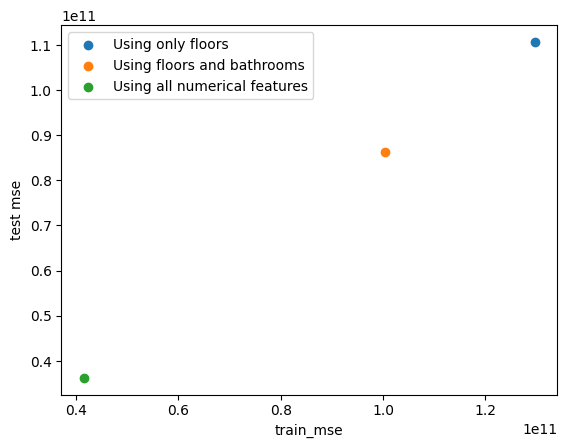

In [21]:
plt.scatter([train_mse_floors], [test_mse_floors], label="Using only floors")
plt.scatter([train_mse_floors_bathrooms], [test_mse_floors_bathrooms], label="Using floors and bathrooms")
plt.scatter([train_mse_all_numerical], [test_mse_all_numerical], label="Using all numerical features")
plt.ylabel("test mse")
plt.xlabel("train_mse")
plt.legend()

In [22]:
cat_columns = housing_df.select_dtypes(include=['object']).columns.tolist()
housing_df_train[cat_columns].head()

,date
5268,20150218T000000
16909,20140808T000000
16123,20150414T000000
12181,20140617T000000
12617,20141020T000000


##### Engineering the date column to the real numerical features

In [23]:
housing_df["date"] = pd.to_datetime(housing_df["date"])

housing_df["year"] = housing_df["date"].dt.year
housing_df["month"] = housing_df["date"].dt.month
housing_df["day"] = housing_df["date"].dt.day
housing_df["dayofweek"] = housing_df["date"].dt.dayofweek
housing_df["quarter"] = housing_df["date"].dt.quarter


In [24]:
housing_df = housing_df.drop(columns=["date"])

In [25]:
housing_df.head()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day,dayofweek,quarter
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,98178,47.5112,-122.257,1340,5650,2014,10,13,0,4
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,98125,47.7210,-122.319,1690,7639,2014,12,9,1,4
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,...,98028,47.7379,-122.233,2720,8062,2015,2,25,2,1
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,98136,47.5208,-122.393,1360,5000,2014,12,9,1,4
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,98074,47.6168,-122.045,1800,7503,2015,2,18,2,1


##### Adding the columns to the initial feature for the model training

In [26]:
new_x_train = housing_df.drop(columns="price")
new_y_train = housing_df["price"]

X_train, X_test, y_train, y_test = train_test_split(new_x_train, new_y_train, test_size=0.2, random_state=42)
# training
linreg.fit(X_train, y_train)

train_mse_all = mean_squared_error(y_train, linreg.predict(X_train))
test_mse_all = mean_squared_error(y_test, linreg.predict(X_test))

##### Drawing a scatter plot for all the features

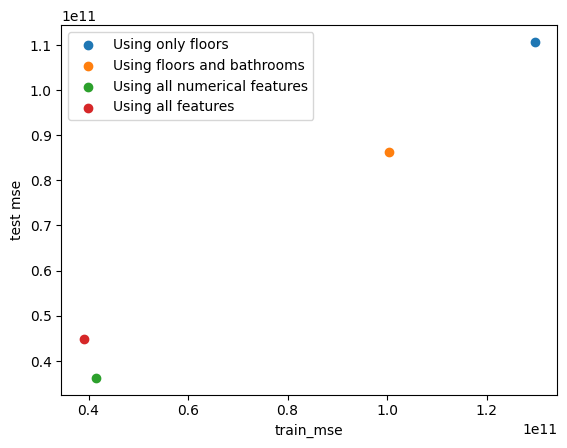

In [27]:
plt.scatter([train_mse_floors], [test_mse_floors], label="Using only floors")
plt.scatter([train_mse_floors_bathrooms], [test_mse_floors_bathrooms], label="Using floors and bathrooms")
plt.scatter([train_mse_all_numerical], [test_mse_all_numerical], label="Using all numerical features")
plt.scatter([train_mse_all], [test_mse_all], label="Using all features")
plt.ylabel("test mse")
plt.xlabel("train_mse")
plt.legend()